In [187]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [188]:
df = pd.read_csv("../datasets/Final_ResaleData.csv")
df.head()

,Year,Month,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall,Within_1km_of_Pri,Mature
0,2017,1,10,44.0,61.333,232000.0,1148,1276,True,True
1,2017,1,1,67.0,60.583,250000.0,268,1612,True,True
2,2017,1,1,67.0,62.417,262000.0,795,2278,True,True
3,2017,1,4,68.0,62.083,265000.0,1186,1333,True,True
4,2017,1,1,67.0,62.417,265000.0,735,2323,True,True


In [189]:
# find df shape
print("Dataframe shape: ", df.shape)

df.info()

Dataframe shape:  (212868, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212868 entries, 0 to 212867
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Year               212868 non-null  int64  
 1   Month              212868 non-null  int64  
 2   Storey             212868 non-null  int64  
 3   Floor_Area         212868 non-null  float64
 4   Remaining_Lease    212868 non-null  float64
 5   Price              212868 non-null  float64
 6   Distance_MRT       212868 non-null  int64  
 7   Distance_Mall      212868 non-null  int64  
 8   Within_1km_of_Pri  212868 non-null  bool   
 9   Mature             212868 non-null  bool   
dtypes: bool(2), float64(3), int64(5)
memory usage: 13.4 MB


In [190]:
df.describe()

,Year,Month,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall
count,212868.000000,212868.000000,212868.000000,212868.000000,212868.000000,212868.000000,212868.000000,212868.000000
mean,2021.082300,6.514455,7.584503,96.414865,74.194438,510213.368192,1077.931065,1309.502194
std,2.467264,3.361427,5.621582,23.830564,14.202390,167007.223313,575.167499,672.138370
min,2017.000000,1.000000,1.000000,31.000000,40.083000,140000.000000,48.000000,49.000000
25%,2019.000000,4.000000,4.000000,77.000000,62.500000,380000.000000,660.000000,821.000000
50%,2021.000000,7.000000,7.000000,93.000000,74.000000,485000.000000,966.000000,1197.000000
75%,2023.000000,9.000000,10.000000,112.000000,88.500000,618000.000000,1376.000000,1689.000000
max,2025.000000,12.000000,49.000000,215.000000,97.750000,985000.000000,6250.000000,5374.000000


## Find out distribution of features

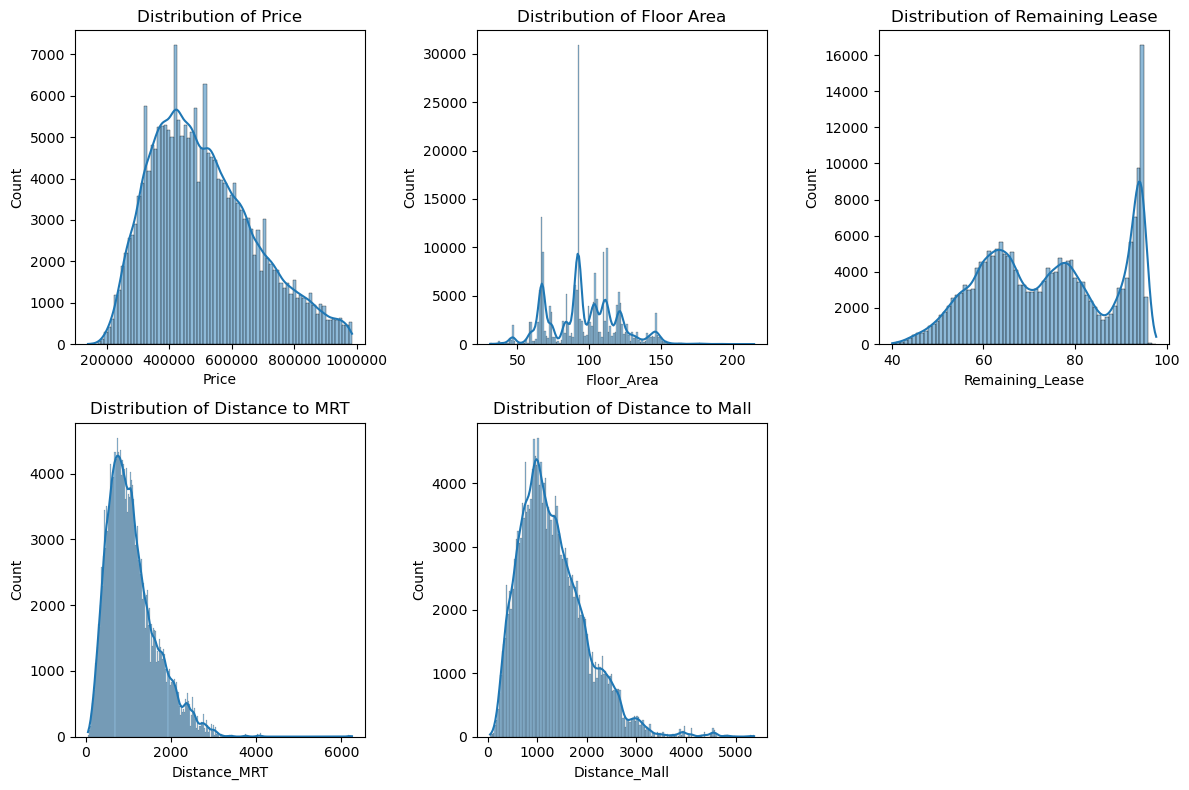

In [191]:

fig, axes = plt.subplots(2, 3, figsize=(12, 8))  
axes = axes.flatten() 

sns.histplot(df["Price"], kde=True, ax=axes[0], bins=80)
axes[0].set_title("Distribution of Price")
axes[0].ticklabel_format(style='plain', axis='x')

sns.histplot(df["Floor_Area"], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Floor Area")

sns.histplot(df["Remaining_Lease"], kde=True, ax=axes[2])
axes[2].set_title("Distribution of Remaining Lease")

sns.histplot(df["Distance_MRT"], kde=True, ax=axes[3])
axes[3].set_title("Distribution of Distance to MRT")

sns.histplot(df["Distance_Mall"], kde=True, ax=axes[4])
axes[4].set_title("Distribution of Distance to Mall")

# Hide any unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


## Distribution of resale price across time

<Axes: xlabel='Year', ylabel='Price'>

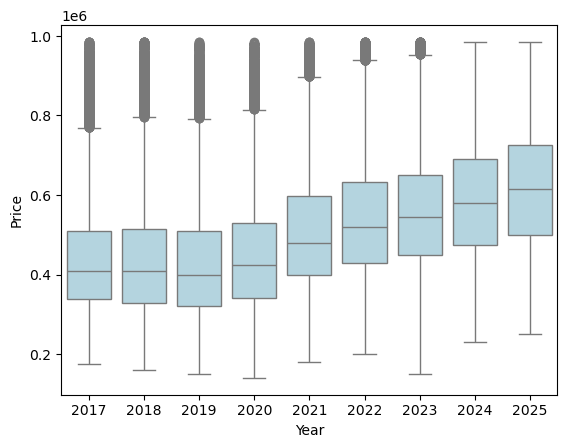

In [192]:
# distribution by prices
sns.boxplot(x=df["Year"], y=df["Price"], color="lightblue")

In [193]:
# print years
print(df['Year'].unique())

[2017 2018 2019 2020 2021 2022 2023 2024 2025]


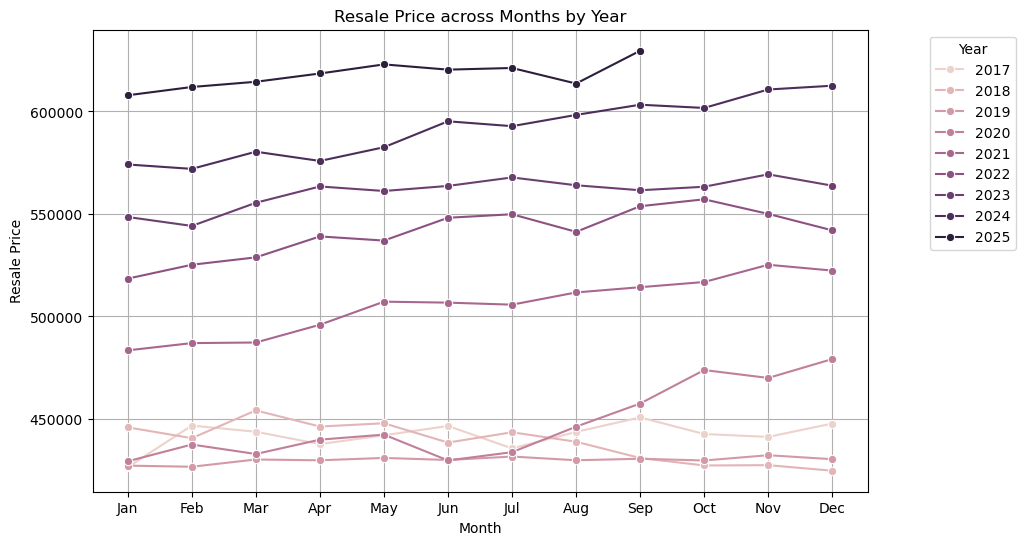

In [194]:
plt.figure(figsize=(10, 6)) 
sns.lineplot(x="Month", y="Price", hue="Year", data=df, marker="o", errorbar=None)
plt.legend(title = 'Year', loc = 'upper right', frameon = True, labels=[str(year) for year in df['Year'].unique()], bbox_to_anchor=(1.2, 1))

plt.xticks(ticks=np.arange(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title("Resale Price across Months by Year")
plt.xlabel("Month")
plt.ylabel("Resale Price")
plt.grid(True)

Price of resale flats increased from 2017 - 2025. There are no particular months across the years that have a consistent higher/lower price in comparison to other years. 

## Find relationship between features and resale prices
1. Correlation to see overview of relationship between variables
2. Grouped features with large range of values and rounded down to nearest 10 to find the median price
3. Plotted line graph of Price against each feature to measure their relationship

<Axes: >

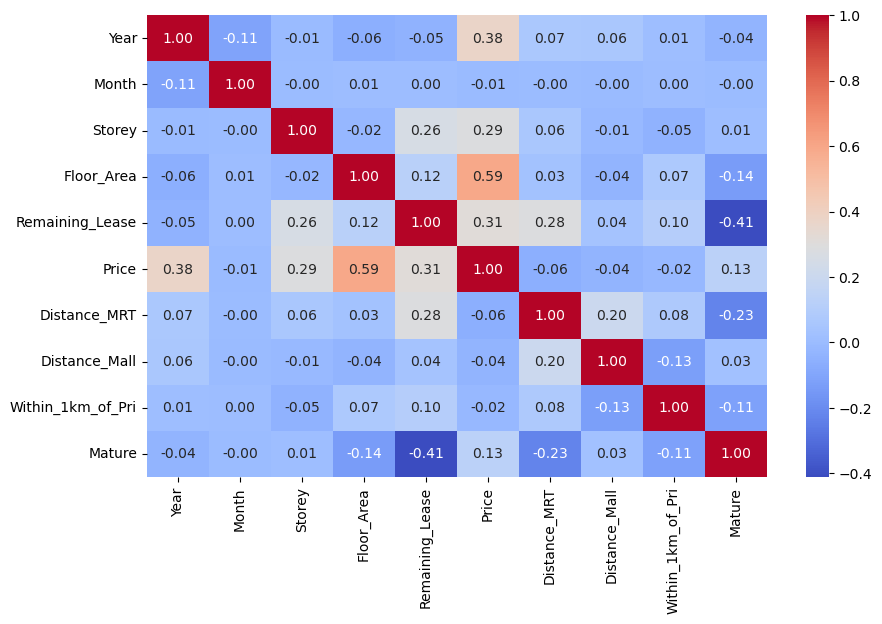

In [195]:
# correlation heatmap
plt.figure(figsize=(10, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

In [196]:
# increment floor area by 10 by rounding down to nearest 10
df['Floor_Area_Encoded'] = (df['Floor_Area'] // 10) * 10

# mean price by floor area
med_area = df.groupby('Floor_Area_Encoded')['Price'].median().reset_index()

# increment remaining lease by 10 by rounding down to nearest 10
df['Remaining_Lease_Encoded'] = (df['Remaining_Lease'] // 10) * 10

# mean price by remaining lease
med_lease = df.groupby('Remaining_Lease_Encoded')['Price'].median().reset_index()

# increment distance to MRT by 500 by rounding down to nearest 500
df['Distance_MRT_Encoded'] = (df['Distance_MRT'] // 500) * 500

# mean price by distance to MRT
med_mrt = df.groupby('Distance_MRT_Encoded')['Price'].median().reset_index()

# increment distance to Mall by 500 by rounding down to nearest 500
df['Distance_Mall_Encoded'] = (df['Distance_Mall'] // 500) * 500

# mean price by distance to Mall
med_mall = df.groupby('Distance_Mall_Encoded')['Price'].median().reset_index()

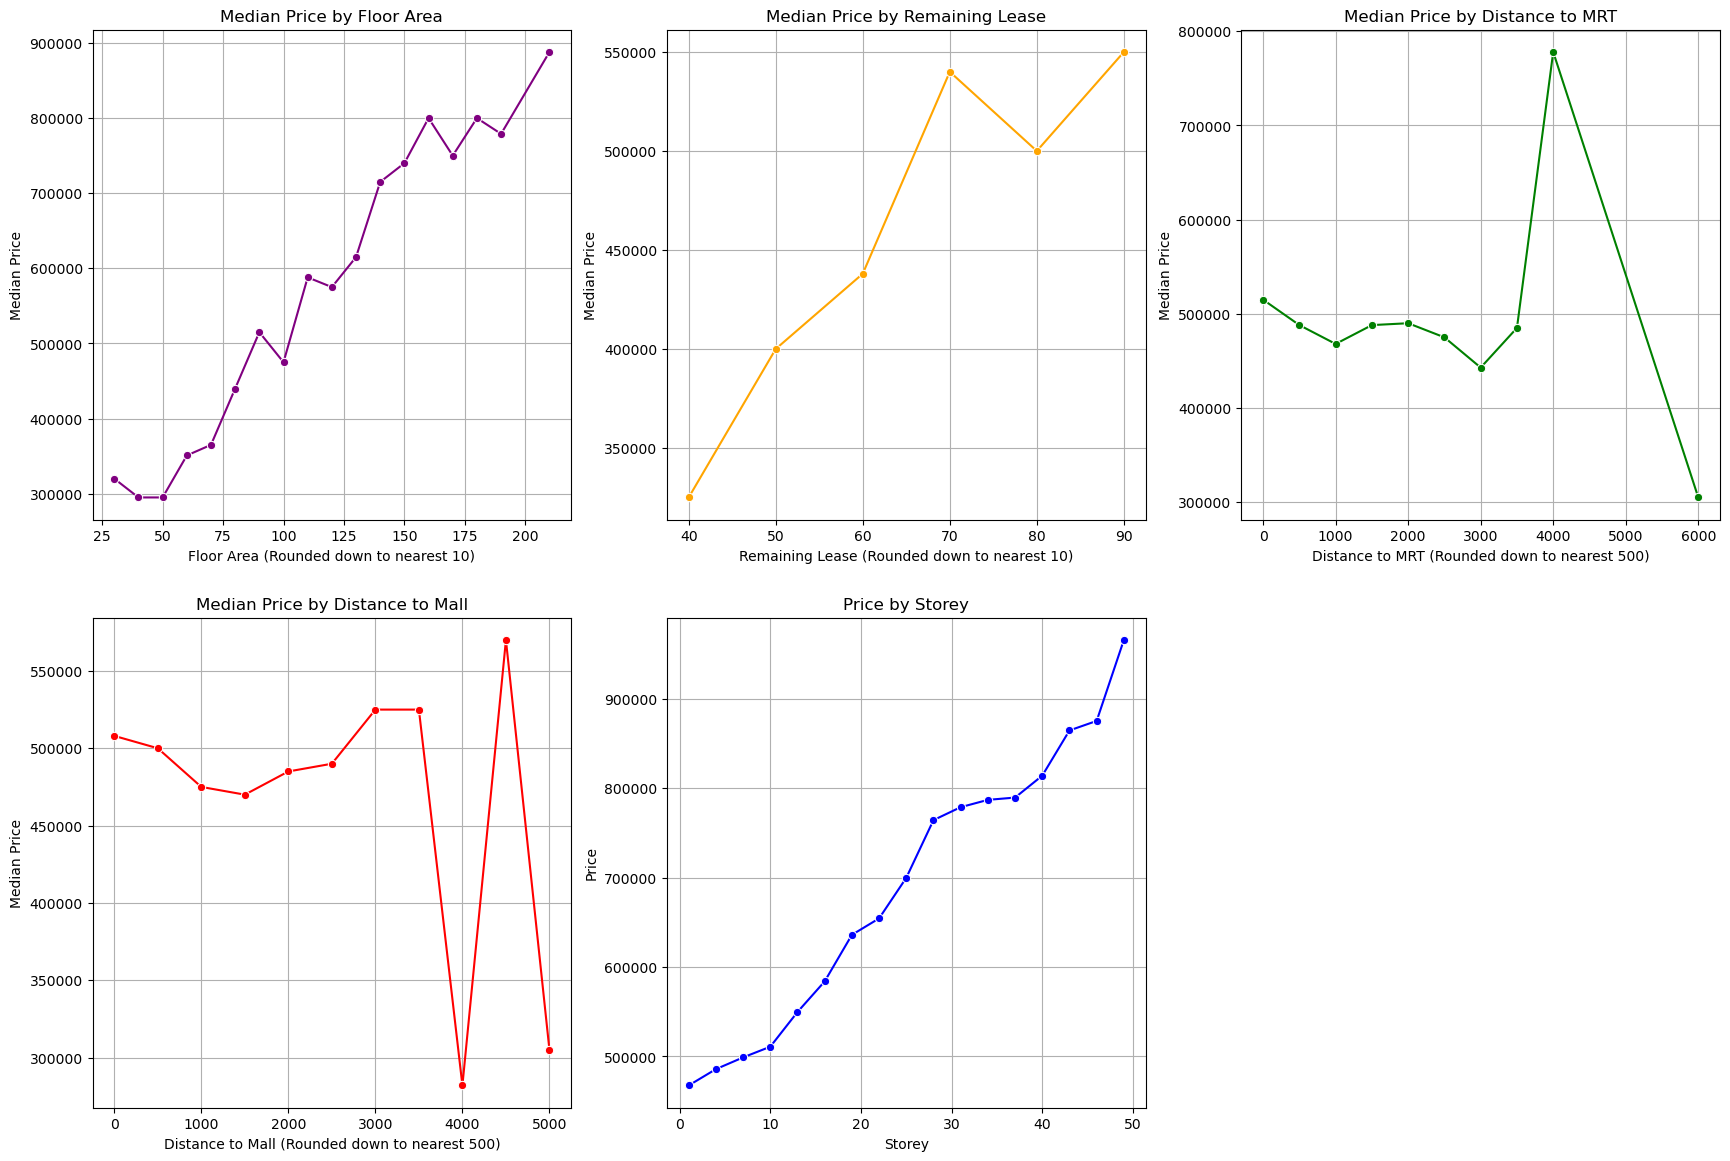

In [197]:
fig, axes = plt.subplots(2, 3, figsize=(21, 14))
axes = axes.flatten()

sns.lineplot(x=med_area['Floor_Area_Encoded'], y=med_area['Price'], marker='o', color='purple', ax=axes[0])
axes[0].set_title("Median Price by Floor Area")
axes[0].set_xlabel("Floor Area (Rounded down to nearest 10)")
axes[0].set_ylabel("Median Price")
axes[0].ticklabel_format(style='plain', axis='x')
axes[0].grid(True)

sns.lineplot(x=med_lease['Remaining_Lease_Encoded'], y=med_lease['Price'], marker='o', color='orange', ax=axes[1])
axes[1].set_title("Median Price by Remaining Lease")
axes[1].set_xlabel("Remaining Lease (Rounded down to nearest 10)")
axes[1].set_ylabel("Median Price")
axes[1].ticklabel_format(style='plain', axis='x')
axes[1].grid (True)

sns.lineplot(x=med_mrt['Distance_MRT_Encoded'], y=med_mrt['Price'], marker='o', color='green', ax=axes[2])
axes[2].set_title("Median Price by Distance to MRT")
axes[2].set_xlabel("Distance to MRT (Rounded down to nearest 500)")
axes[2].set_ylabel("Median Price")
axes[2].ticklabel_format(style='plain', axis='x')
axes[2].grid (True)

sns.lineplot(x=med_mall['Distance_Mall_Encoded'], y=med_mall['Price'], marker='o', color='red', ax=axes[3])
axes[3].set_title("Median Price by Distance to Mall")
axes[3].set_xlabel("Distance to Mall (Rounded down to nearest 500)")
axes[3].set_ylabel("Median Price")
axes[3].ticklabel_format(style='plain', axis='x')
axes[3].grid (True)

sns.lineplot(x=df['Storey'], y=df['Price'], marker='o', color='blue', ax=axes[4], errorbar=None)
axes[4].set_title("Price by Storey")
axes[4].set_xlabel("Storey")
axes[4].set_ylabel("Price")
axes[4].ticklabel_format(style='plain', axis='x')
axes[4].grid (True)

fig.delaxes(axes[5])

From the graph above, feeaures like `Floor_Area`, `Remaining_Lease` and `Storey` have higher correlation to price than `Distance_to_MRT` and `Distance to Mall`